In [58]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import os

In [70]:
# === CONFIGURATION ===
input_path = "buildingfootprint_trial.png"
output_geojson_path = "building_contours.geojson"

In [65]:
# === STEP 1: Load grayscale image ===
image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(f"Image not found at {input_path}")

In [66]:
# === STEP 2: Canny Edge Detection ===
edges = cv2.Canny(image, 50, 150)  # Try (30, 120) or (60, 180) for different sensitivity

# === STEP 3: Morphological Closing ===
kernel = np.ones((3, 3), np.uint8)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# === STEP 4: Find all contours (internal + external) ===
contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"Detected {len(contours)} raw contours")

# === STEP 5: Filter small contours by area ===
min_area = 200  # Increase to 400+ if roads still included
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
print(f"Filtered to {len(filtered_contours)} contours > {min_area} px")

Detected 1091 raw contours
Filtered to 671 contours > 200 px


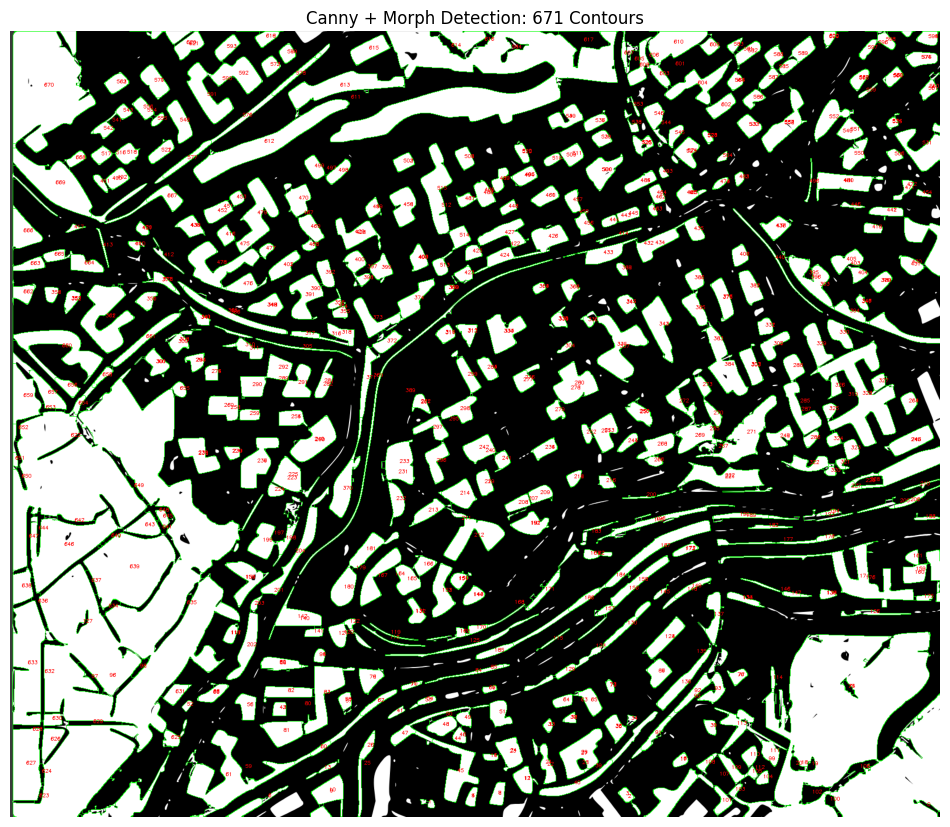

In [67]:
# === STEP 6: Preview — draw contours and label IDs ===
preview = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for i, cnt in enumerate(filtered_contours):
    cv2.drawContours(preview, [cnt], -1, (0, 255, 0), 1)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(preview, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"Canny + Morph Detection: {len(filtered_contours)} Contours")
plt.axis("off")
plt.show()

Detected 1091 raw contours
Filtered to 671 contours > 200 px


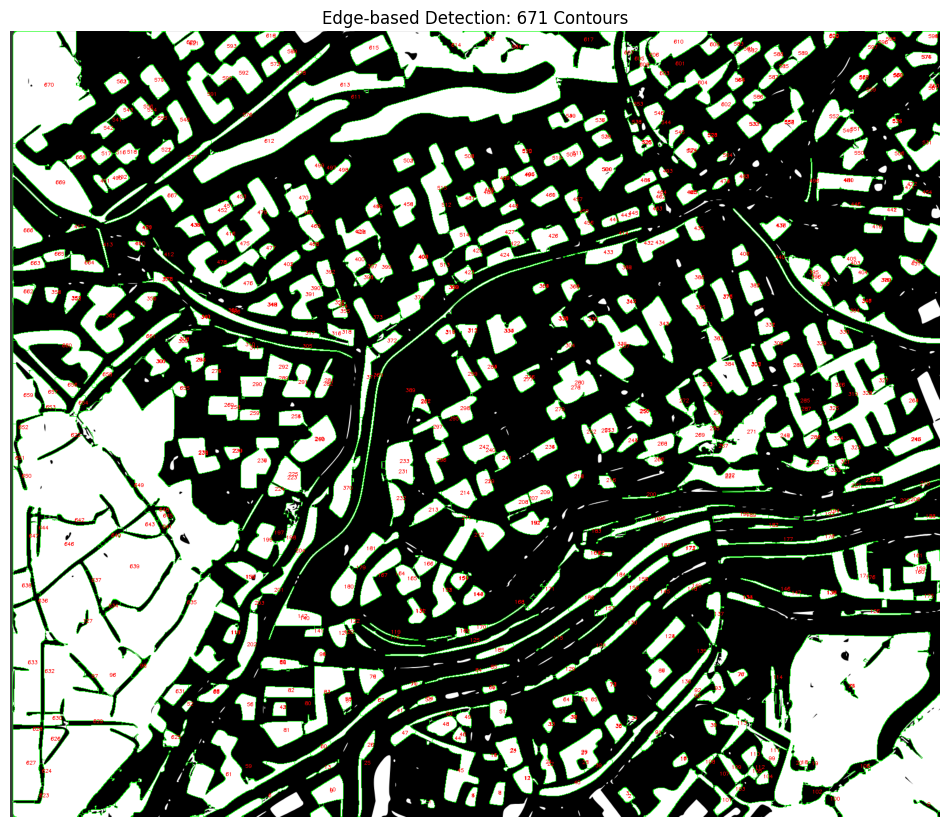

In [68]:
# === Improved: Edge Detection + Morph Closing ===

# 1. Apply Canny Edge Detection (tune thresholds if needed)
edges = cv2.Canny(image, 50, 150)

# 2. Apply Morphological Closing to connect outlines
kernel = np.ones((3, 3), np.uint8)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# 3. Find contours (inner + outer)
contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"Detected {len(contours)} raw contours")

# 4. Filter by area to ignore tiny specks
min_area = 200
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
print(f"Filtered to {len(filtered_contours)} contours > {min_area} px")

# 5. Draw + label preview
preview = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for i, cnt in enumerate(filtered_contours):
    cv2.drawContours(preview, [cnt], -1, (0, 255, 0), 1)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(preview, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"Edge-based Detection: {len(filtered_contours)} Contours")
plt.axis("off")
plt.show()

In [71]:
# === STEP 7: Export contours to GeoJSON ===
features = []
for cnt in filtered_contours:
    coords = cnt.squeeze().tolist()
    if not coords or isinstance(coords[0], int) or len(coords) < 3:
        continue
    if coords[0] != coords[-1]:  # Ensure closed polygon
        coords.append(coords[0])
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [coords]
        },
        "properties": {}
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(output_geojson_path, "w") as f:
    json.dump(geojson, f, indent=2)

print(f"✅ GeoJSON exported: {output_geojson_path}")

✅ GeoJSON exported: building_contours.geojson


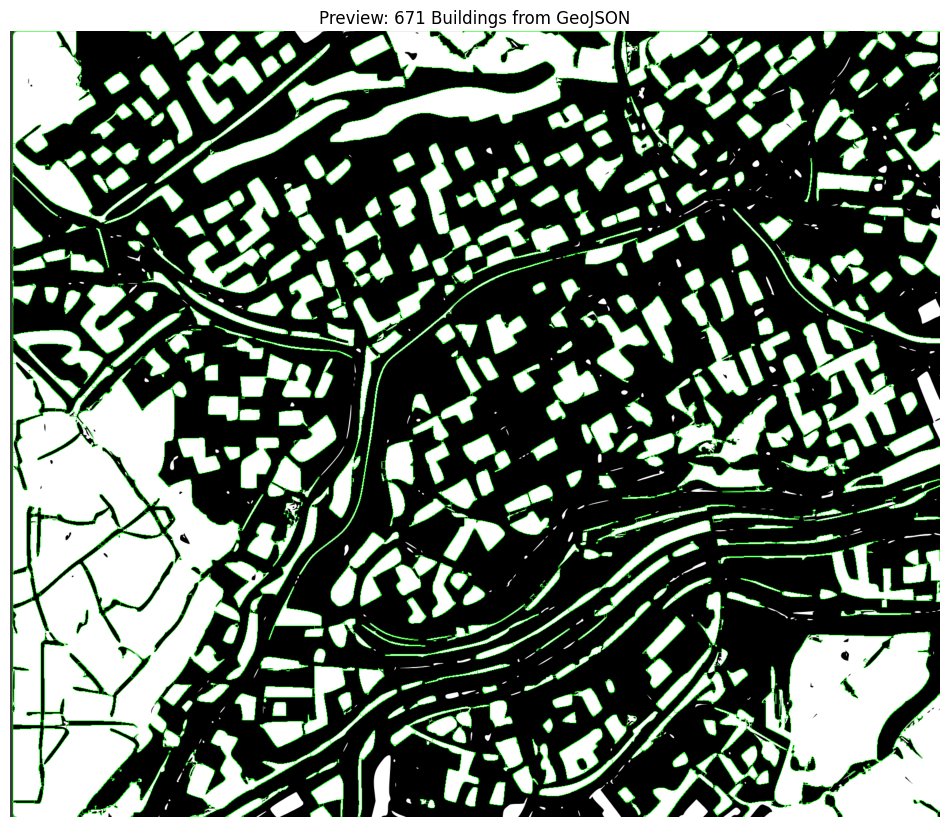

In [72]:
# === Load image again for overlay ===
background = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
background_rgb = cv2.cvtColor(background, cv2.COLOR_GRAY2RGB)

# === Load GeoJSON ===
with open(output_geojson_path, "r") as f:
    data = json.load(f)

# === Draw polygons from GeoJSON ===
for feature in data["features"]:
    coords = np.array(feature["geometry"]["coordinates"][0], dtype=np.int32)
    cv2.polylines(background_rgb, [coords], isClosed=True, color=(0, 255, 0), thickness=1)

# === Show result ===
plt.figure(figsize=(12, 12))
plt.imshow(background_rgb)
plt.title(f"Preview: {len(data['features'])} Buildings from GeoJSON")
plt.axis("off")
plt.show()
